In [20]:
import pandas as pd
import numpy as np

# Load real Steam PC games dataset from permanent raw mirror
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-03-16/games.csv"
df_games = pd.read_csv(url)

# Inspect shape and messy columns
print("Dataset Shape:", df_games.shape)
print("\nFirst 5 rows:")
print(df_games[['gamename', 'year', 'month', 'avg', 'gain', 'avg_peak_perc']].head())

Dataset Shape: (83631, 7)

First 5 rows:
                           gamename  year     month        avg      gain  \
0  Counter-Strike: Global Offensive  2021  February  741013.24  -2196.42   
1                            Dota 2  2021  February  404832.13 -27839.52   
2     PLAYERUNKNOWN'S BATTLEGROUNDS  2021  February  198957.52  -2289.67   
3                      Apex Legends  2021  February  120982.64  49215.90   
4                              Rust  2021  February  117742.27 -24374.98   

  avg_peak_perc  
0      65.9567%  
1      62.1275%  
2      44.4707%  
3      61.4752%  
4      52.4988%  


In [21]:
df_games.head()

,gamename,year,month,avg,gain,peak,avg_peak_perc
0,Counter-Strike: Global Offensive,2021,February,741013.24,-2196.42,1123485,65.9567%
1,Dota 2,2021,February,404832.13,-27839.52,651615,62.1275%
2,PLAYERUNKNOWN'S BATTLEGROUNDS,2021,February,198957.52,-2289.67,447390,44.4707%
3,Apex Legends,2021,February,120982.64,49215.90,196799,61.4752%
4,Rust,2021,February,117742.27,-24374.98,224276,52.4988%


In [22]:
df_games.isna().sum()

gamename            0
year                0
month               0
avg                 0
gain             1258
peak                0
avg_peak_perc       0
dtype: int64

In [23]:
df_games.avg_peak_perc=pd.to_numeric(df_games.avg_peak_perc.str.strip('%'),errors='coerce')

In [24]:
df_games['date'] = df_games.year.astype(str) + ' ' + df_games.month.astype(str)

In [25]:
df_games.date=pd.to_datetime(df_games.date)

C:\Users\engma\AppData\Local\Temp\ipykernel_6532\1231918537.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_games.date=pd.to_datetime(df_games.date)


In [28]:
df_games.head()

,gamename,year,month,avg,gain,peak,avg_peak_perc,date
0,Counter-Strike: Global Offensive,2021,February,741013.24,-2196.42,1123485,65.9567,2021-02-01
1,Dota 2,2021,February,404832.13,-27839.52,651615,62.1275,2021-02-01
2,PLAYERUNKNOWN'S BATTLEGROUNDS,2021,February,198957.52,-2289.67,447390,44.4707,2021-02-01
3,Apex Legends,2021,February,120982.64,49215.90,196799,61.4752,2021-02-01
4,Rust,2021,February,117742.27,-24374.98,224276,52.4988,2021-02-01


In [29]:
df_games.gain=pd.to_numeric(df_games.gain,errors='coerce')

In [32]:
df_games.dtypes

gamename                 object
year                      int64
month                    object
avg                     float64
gain                    float64
peak                      int64
avg_peak_perc           float64
date             datetime64[ns]
dtype: object

In [33]:
df_games.fillna(0,inplace=True)

In [34]:
df_games.groupby('gamename')['avg'].mean().sort_values(ascending=False).head()

gamename
PLAYERUNKNOWN'S BATTLEGROUNDS       482024.881458
Dota 2                              453731.936346
Counter-Strike: Global Offensive    308644.838846
Cyberpunk 2077                      146415.716667
Apex Legends                         83044.097500
Name: avg, dtype: float64

In [35]:
Dota=df_games[df_games.gamename == 'Dota 2']

In [36]:
Dota

,gamename,year,month,avg,gain,peak,avg_peak_perc,date
1,Dota 2,2021,February,404832.13,-27839.52,651615,62.1275,2021-02-01
1258,Dota 2,2021,January,432671.65,10119.33,694613,62.2896,2021-01-01
2513,Dota 2,2020,December,422552.32,-3352.52,697833,60.5521,2020-12-01
3763,Dota 2,2020,November,425904.83,19543.48,711824,59.8329,2020-11-01
5007,Dota 2,2020,October,406361.36,-2248.43,723280,56.1831,2020-10-01
...,...,...,...,...,...,...,...,...
82481,Dota 2,2012,November,101077.43,25111.99,169631,59.5866,2012-11-01
82739,Dota 2,2012,October,75965.44,14097.77,171860,44.2019,2012-10-01
82984,Dota 2,2012,September,61867.68,6099.07,118724,52.1105,2012-09-01
83215,Dota 2,2012,August,55768.61,3047.56,108689,51.3103,2012-08-01


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

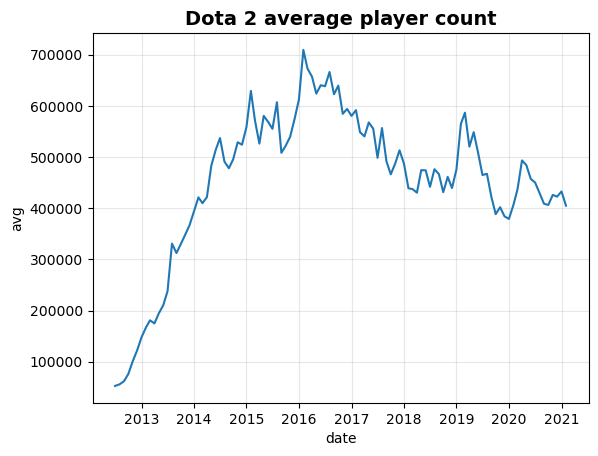

In [38]:
sns.lineplot(Dota,x='date',y='avg')
plt.title('Dota 2 average player count', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()